# ACS Exploratory Data Analysis
## Project Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
acs = pd.read_csv("pums_short.csv.gz")

## Data Overview

In [3]:
print(f"Rows: {acs.shape[0]}")
print(f"Columns: {acs.shape[1]}")

Rows: 276632
Columns: 31


In [4]:
acs.head()

,DIVISION,PUMA,REGION,ST,NP,MRGP,RNTP,TEN,VALP,VEH,...,NRC,PARTNER,R18,R60,R65,TAXAMT,WIF,WKEXREL,WORKSTAT,FFINCP
0,6,800,3,1,4,550.0,NaN,1.0,60000.0,4.0,...,1.0,0.0,1.0,0.0,0.0,325.0,3.0,1.0,1.0,0
1,6,2500,3,1,1,NaN,NaN,2.0,120000.0,1.0,...,0.0,0.0,0.0,1.0,1.0,625.0,NaN,NaN,NaN,0
2,6,2702,3,1,3,NaN,120.0,3.0,NaN,2.0,...,2.0,0.0,1.0,0.0,0.0,NaN,0.0,15.0,15.0,0
3,6,1303,3,1,1,NaN,650.0,3.0,NaN,1.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0
4,6,2000,3,1,5,NaN,950.0,3.0,NaN,3.0,...,1.0,0.0,1.0,0.0,0.0,NaN,3.0,2.0,1.0,0


### Column Names

In [5]:
acs.columns.tolist()

['DIVISION',
 'PUMA',
 'REGION',
 'ST',
 'NP',
 'MRGP',
 'RNTP',
 'TEN',
 'VALP',
 'VEH',
 'YBL',
 'FES',
 'FINCP',
 'FPARC',
 'HHT',
 'HINCP',
 'HUPAC',
 'MV',
 'NOC',
 'NPF',
 'NR',
 'NRC',
 'PARTNER',
 'R18',
 'R60',
 'R65',
 'TAXAMT',
 'WIF',
 'WKEXREL',
 'WORKSTAT',
 'FFINCP']

### Column Types

In [6]:
acs.info()

<class 'pandas.DataFrame'>
RangeIndex: 276632 entries, 0 to 276631
Data columns (total 31 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   DIVISION  276632 non-null  int64  
 1   PUMA      276632 non-null  int64  
 2   REGION    276632 non-null  int64  
 3   ST        276632 non-null  int64  
 4   NP        276632 non-null  int64  
 5   MRGP      103923 non-null  float64
 6   RNTP      73904 non-null   float64
 7   TEN       251019 non-null  float64
 8   VALP      178988 non-null  float64
 9   VEH       251019 non-null  float64
 10  YBL       276632 non-null  int64  
 11  FES       164443 non-null  float64
 12  FINCP     165749 non-null  float64
 13  FPARC     165749 non-null  float64
 14  HHT       251019 non-null  float64
 15  HINCP     251019 non-null  float64
 16  HUPAC     251019 non-null  float64
 17  MV        251019 non-null  float64
 18  NOC       251019 non-null  float64
 19  NPF       165749 non-null  float64
 20  NR        25101

### Variable of Interest

In [10]:
selected_cols = [
    "DIVISION",
    "REGION",
    "ST",
    "HINCP",    # household income
    "FINCP",    # family income
    "VALP",     # property value
    "RNTP",     # monthly rent
    "R65",      # presence of people 65+
    "TEN",      # tenure / ownership
    "NP",       # number of persons
    "VEH"       # vehicles
]

acs_selected = acs[selected_cols].copy()
acs_selected.head()

,DIVISION,REGION,ST,HINCP,FINCP,VALP,RNTP,R65,TEN,NP,VEH
0,6,3,1,70000.0,70000.0,60000.0,NaN,0.0,1.0,4,4.0
1,6,3,1,7000.0,NaN,120000.0,NaN,1.0,2.0,1,1.0
2,6,3,1,9000.0,9000.0,NaN,120.0,0.0,3.0,3,2.0
3,6,3,1,52000.0,NaN,NaN,650.0,0.0,3.0,1,1.0
4,6,3,1,74800.0,74800.0,NaN,950.0,0.0,3.0,5,3.0


## Missing Values

In [12]:
missing_summary = (
    acs_selected.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["column", "missing_proportion"]
missing_summary

,column,missing_proportion
0,RNTP,0.732844
1,FINCP,0.400832
2,VALP,0.352974
3,R65,0.092589
4,TEN,0.092589
5,VEH,0.092589
6,HINCP,0.092589
7,ST,0.000000
8,REGION,0.000000
9,DIVISION,0.000000


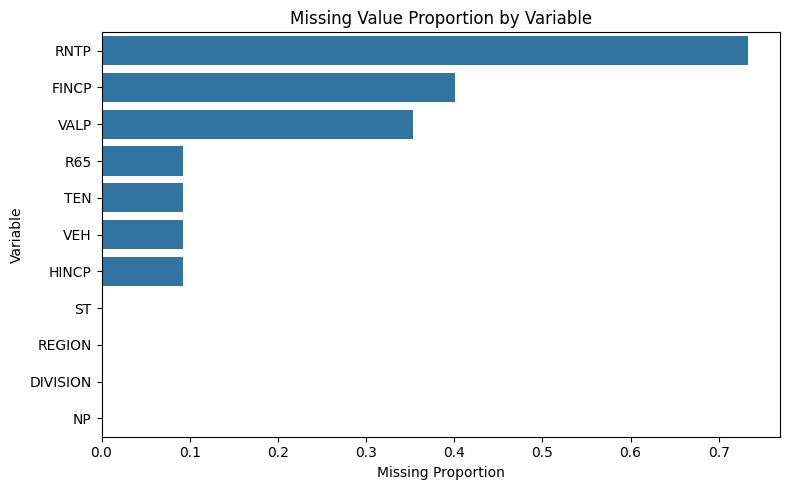

In [21]:
plt.figure(figsize=(8, 5))
sb.barplot(
    data=missing_summary,
    x="missing_proportion",
    y="column"
)
plt.title("Missing Value Proportion by Variable")
plt.xlabel("Missing Proportion")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

The "RNTP" (monthly rant) has substantial misses because the rent only applies to rental housing units.

## Household Income

In [16]:
income = acs_selected["HINCP"].dropna()
print("===== Household Income Summary =====")
income.describe()

===== Household Income Summary =====


count    2.510190e+05
mean     8.965029e+04
std      1.000946e+05
min     -1.640000e+04
25%      3.180000e+04
50%      6.300000e+04
75%      1.110000e+05
max      2.580000e+06
Name: HINCP, dtype: float64

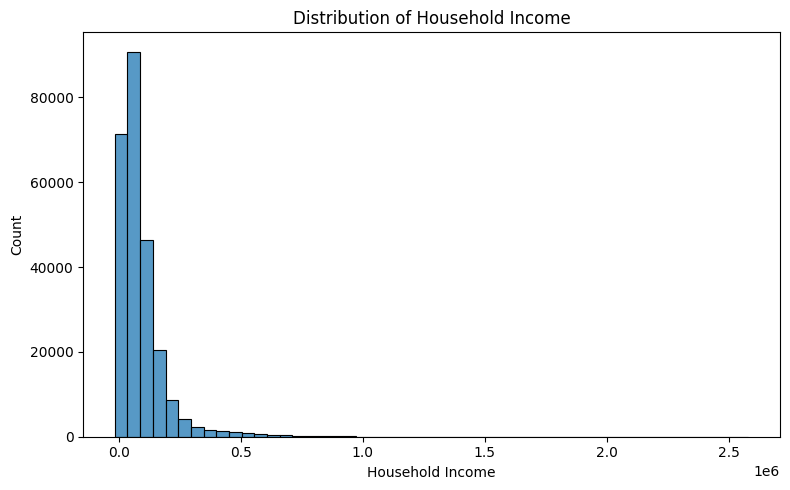

In [18]:
plt.figure(figsize=(8, 5))
sb.histplot(income, bins=50)
plt.title("Distribution of Household Income")
plt.xlabel("Household Income")
plt.ylabel("Count")
plt.tight_layout()

Since the income is right skewed, log scale can be applied.

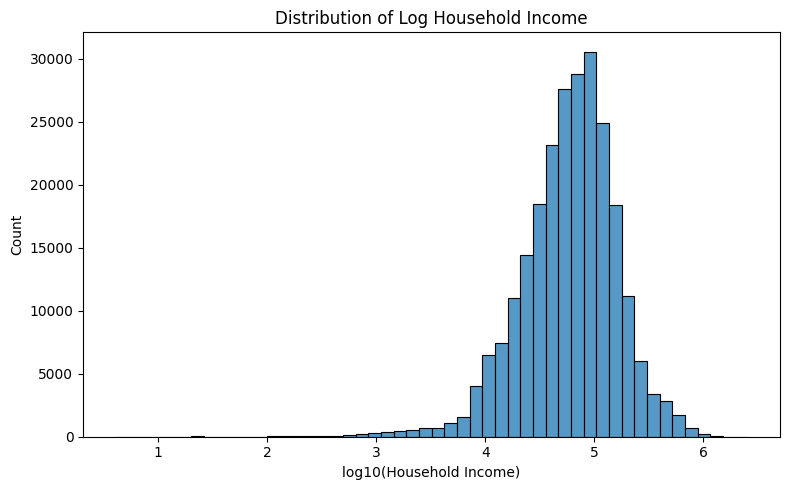

In [20]:
income_positive = income[income > 0]

plt.figure(figsize=(8, 5))
sb.histplot(np.log10(income_positive), bins=50)
plt.title("Distribution of Log Household Income")
plt.xlabel("log10(Household Income)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()